In [1]:
import sys
sys.path.append("../../")
from src.services.opensearch import OpenSearchClient
from src.services.embedding_processor import VectorProcessor
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
import pandas as pd

from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

True

### Instantiate rag tool

In [2]:
chat = ChatOpenAI(model="gpt-4o", temperature=0.0)

system_prompt = """
You are the QA Extraction Agent within a multi-agent architecture.
Your task is to answer the specific question routed to you by the "Router Decomposition" agent, using strictly the retrieved context from a vector database.

<CRITICAL_RULES>
1. STRICT GROUNDING: You must formulate your answer using ONLY the information provided in the <CONTEXT_REFERENCE>. Absolutely no external knowledge or assumptions are allowed.
2. EXHAUSTIVE EXTRACTION: Explore the provided context deeply. Extract all relevant details, nuances, and data points to provide the most comprehensive answer possible based solely on the text.
3. ADMIT IGNORANCE: If the provided context does NOT contain sufficient information to answer the <ROUTER_QUESTION>, you MUST explicitly state that. Do not attempt to guess, hallucinate, or infer outside the boundaries of the provided text.
</CRITICAL_RULES>
"""

user_prompt = """
Please analyze the context below and answer the routed question according to your system instructions.

<ROUTER_QUESTION>
{input_question}
</ROUTER_QUESTION>

<CONTEXT_REFERENCE>
{chunks_list}
</CONTEXT_REFERENCE>
"""


def rag_pretty_print(chunks):
    for chunk in chunks:
        source = chunk["_source"]
        print(f"Score: {chunk['_score']}")
        print(f"Página: {source['page_number']} | Ordem: {source['reading_order']}")
        print(f"Seção: {source['section_context']}")
        print(f"Conteúdo: {source['content'][:200]}...")
        print("---")


def list_content(chunks):
    all_content = []
    for chunk in chunks:
        source = chunk["_source"]['content']
        all_content.append(source)
    return all_content

client = OpenSearchClient()
vector_processor = VectorProcessor()

2026-03-30 14:11:00 - src.services.opensearch - INFO - Connection with OpenSearch has been achieved. Version: 3.5.0
2026-03-30 14:11:03 - src.services.embedding_processor - INFO - Embed Model successfully loaded. Its dimensions is: 3072


In [36]:
def reorder_chunks_by_score(chunks: list) -> list:
    return sorted(chunks, key=lambda x: x["_score"], reverse=True)

<hr><hr>

In [3]:
df = pd.read_csv(r"../../data/dataset_evaluation/ground_truth_dataset.csv")
df.columns = ["book", "question", "reference", "chunks_reference", "metadata_reference"]

In [64]:
df.head(3)

,Unnamed: 0,question,answer,contexts,ground_truth,faithfulness,context_precision,context_recall,answer_correctness,answer_relevancy
0,0,What evidence is presented regarding the impac...,The evidence presented regarding the impact of...,[ABSTRACT\n\nCode comprehension is crucial in ...,The evidence regarding the impact of atoms of ...,0.846154,0.770833,0.833333,0.852678,0.969227
1,1,What are the identified 'atoms of confusion' i...,The study identified 'atoms of confusion' as s...,[ABSTRACT\n\nCode comprehension is crucial in ...,Atoms of confusion are small code patterns in ...,1.000000,1.000000,0.250000,0.650784,0.951663
2,2,What experimental design was employed in the s...,The study employed a controlled experimental d...,[ABSTRACT\n\nCode comprehension is crucial in ...,The study employed a Latin Square design to as...,1.000000,0.750000,1.000000,0.646139,0.929804


In [5]:
questions = df["question"]
vector_questions = vector_processor.embedding_model.embed_documents(questions)

test_cases = []
for index, row in df.iterrows():
    metadata_chunks = {}
    metadata_chunks["book_id"] = row["book"].split(".")[0].strip() + ".pdf"
    metadata_chunks["question"] = row["question"]
    metadata_chunks["vector_question"] = vector_questions[index]
    test_cases.append(metadata_chunks)

In [6]:
test_cases[0]

{'book_id': 'atoms_confusion.pdf',
 'question': 'What evidence is presented regarding the impact of atoms of confusion on code comprehension, particularly in terms of time, accuracy, and visual attention, as observed in studies utilizing eye-tracking technology?',
 'vector_question': [-0.00230371649377048,
  0.01567402109503746,
  -0.021710341796278954,
  0.009265897795557976,
  -0.0032605607993900776,
  -0.019115014001727104,
  0.029642123728990555,
  0.019523268565535545,
  -0.02297884225845337,
  -0.005285425577312708,
  0.01829850673675537,
  -0.026696866378188133,
  -0.011423809453845024,
  -0.005128685384988785,
  0.023941155523061752,
  0.0014471129979938269,
  0.014835642650723457,
  0.024043219164013863,
  -0.022526847198605537,
  -0.01415035966783762,
  0.050098542124032974,
  -0.0516149140894413,
  -0.04076703265309334,
  -0.0017624159809201956,
  0.008711839094758034,
  0.010585431940853596,
  0.0034227685537189245,
  -0.01840057037770748,
  -0.02071886882185936,
  0.003584

In [63]:
contexts = []
messages_list = []

for each_case in test_cases:
    chunks = client.semantic_search(
        index_name="content-pdfs",
        query_vector=each_case["vector_question"],
        book_id=each_case["book_id"],
        k=7
    )
    listed_chunks = list_content(chunks)
    each_case["context"] = listed_chunks
    contexts.append(listed_chunks)
    prompt = user_prompt.format(input_question=each_case["question"], chunks_list=listed_chunks)
    messages = [SystemMessage(system_prompt), HumanMessage(prompt)]
    messages_list.append(messages)

df["contexts"] = contexts

2026-03-30 16:16:19 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'
2026-03-30 16:16:19 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'
2026-03-30 16:16:19 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'
2026-03-30 16:16:19 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'
2026-03-30 16:16:19 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'
2026-03-30 16:16:19 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'
2026-03-30 16:16:19 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusi

#### List of ranked chunks

In [65]:
ranked_context = []

for each_case in test_cases:
    chunks = client.semantic_search(
        index_name="content-pdfs",
        query_vector=each_case["vector_question"],
        book_id=each_case["book_id"],
        k=7
    )
    ranked_chunks = reorder_chunks_by_score(chunks)
    ranked_chunks_content = list_content(ranked_chunks)
    ranked_context.append(ranked_chunks_content)

2026-03-30 16:16:58 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'
2026-03-30 16:16:58 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'
2026-03-30 16:16:58 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'
2026-03-30 16:16:58 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'
2026-03-30 16:16:58 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'
2026-03-30 16:16:58 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'
2026-03-30 16:16:58 - src.services.opensearch - INFO - 7 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusi

In [66]:
df["contexts"] = ranked_context

In [67]:
df["contexts"][0]

["1  INTRODUCTION\n\nIn a previous study [4] , researchers conducted a controlled ex-\nperiment to compare the performance, i.e., time and accuracy of\nparticipants when dealing with code with and without atoms of\nconfusion. They have shown that the presence of atoms of confu-\nsion in the code increases misunderstandings and that, however,\nempirical knowledge on the impact of such atoms on code com-\nprehension is still scarce, given the difficulties in measuring code\ncomprehension [18] . On the other hand, the code comprehension\ntask has been gaining new highlighting from researchers in terms of\ntime and accuracy with eye-tracking devices [16] . For instance,\nknown which parts of the code receive more or less attention\ngiven a given task, we have seen that different parts of each atom's\nvisual effort, which is a dimension not considered before [4] or in\nany other study that we are aware. Although time and accuracy are\ngood estimators of code confusion, knowing precisely the

In [68]:
df.head(3)

,Unnamed: 0,question,answer,contexts,ground_truth,faithfulness,context_precision,context_recall,answer_correctness,answer_relevancy
0,0,What evidence is presented regarding the impac...,The evidence presented regarding the impact of...,"[1 INTRODUCTION\n\nIn a previous study [4] , ...",The evidence regarding the impact of atoms of ...,0.846154,0.770833,0.833333,0.852678,0.969227
1,1,What are the identified 'atoms of confusion' i...,The study identified 'atoms of confusion' as s...,[ABSTRACT\n\nCode comprehension is crucial in ...,Atoms of confusion are small code patterns in ...,1.000000,1.000000,0.250000,0.650784,0.951663
2,2,What experimental design was employed in the s...,The study employed a controlled experimental d...,[1 INTRODUCTION\n\nIn this controlled experim...,The study employed a Latin Square design to as...,1.000000,0.750000,1.000000,0.646139,0.929804


In [19]:
print(df["contexts"][0][11])

4 RESULTS AND DISCUSSION > 4.3 RQ: To what extent do atoms of confusion
affect the focus of attention?

In Figure 8 , we could not observe so much difference in the
heatmaps for the Assignment as a Value atom. The developers tend
to focus their attention on the atom region. When the atom is
located, the distance to the nearest atom is measured and it is
extracted. However, we observe that the attention is more restricted
and focused on a relatively smaller area at the right-hand side of
the heatmap compared to a more sparse at the left-hand side. It is
important to emphasize that the color intensity is relative to the
amount of time to solve the code. However, according to Table 1 ,
in addition to the above observations, the results of the SIFT
Gopfinen et al. [4] have shown that this atom causes confusion, and
by intense color on the atom area, we conclude that the participants


In [20]:
messages_list[0]

[SystemMessage(content='\nYou are the QA Extraction Agent within a multi-agent architecture.\nYour task is to answer the specific question routed to you by the "Router Decomposition" agent, using strictly the retrieved context from a vector database.\n\n<CRITICAL_RULES>\n1. STRICT GROUNDING: You must formulate your answer using ONLY the information provided in the <CONTEXT_REFERENCE>. Absolutely no external knowledge or assumptions are allowed.\n2. EXHAUSTIVE EXTRACTION: Explore the provided context deeply. Extract all relevant details, nuances, and data points to provide the most comprehensive answer possible based solely on the text.\n3. ADMIT IGNORANCE: If the provided context does NOT contain sufficient information to answer the <ROUTER_QUESTION>, you MUST explicitly state that. Do not attempt to guess, hallucinate, or infer outside the boundaries of the provided text.\n</CRITICAL_RULES>\n', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='\nPlease analyze the co

In [21]:
ai_responses = chat.batch(messages_list)
answers = [output.content for output in ai_responses]
df["answer"] = answers

In [23]:
df.head(2)

,book,question,reference,chunks_reference,metadata_reference,contexts,answer
0,atoms_confusion.json,What evidence is presented regarding the impac...,The evidence regarding the impact of atoms of ...,"[""Initial Section\n\n<VISUAL_DESCRIPTION>I'm s...","[{""chunk_id"": ""QRQE2pwBDLVoGsO6XmGR"", ""page_nu...",[ABSTRACT\n\nCode comprehension is crucial in ...,The evidence presented regarding the impact of...
1,atoms_confusion.json,What are the identified 'atoms of confusion' i...,Atoms of confusion are small code patterns in ...,"[""Initial Section\n\nLatest updates: https://d...","[{""chunk_id"": ""QhQE2pwBDLVoGsO6XmGR"", ""page_nu...",[ABSTRACT\n\nCode comprehension is crucial in ...,The study identified 'atoms of confusion' as s...


In [40]:
print(type(df["contexts"].iloc[0]))

<class 'list'>


# Metrics Generation

<hr>

>Imports and RAGAS config

<hr>

In [25]:
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from datasets import Dataset

from ragas import evaluate
from ragas.metrics import (
    faithfulness, 
    answer_relevancy,
    answer_correctness,
    context_precision,
    context_recall,
)

c:\Users\Erlonidas\AppData\Local\pypoetry\Cache\virtualenvs\rag-book-storage-qm6-3mjV-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Erlonidas\AppData\Local\Temp\ipykernel_14220\4074234897.py:7: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
C:\Users\Erlonidas\AppData\Local\Temp\ipykernel_14220\4074234897.py:7: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
C:\Users\Erlonidas\AppData\Local\Temp\ipyker

In [26]:
import pandas as pd
import ast
# df = pd.read_csv("test_data_ragas.csv")
# df['contexts'] = df['contexts'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

In [27]:
# Configurar LLM e Embeddings para o Ragas com timeout maior
evaluator_llm = LangchainLLMWrapper(
    ChatOpenAI(
        model="gpt-4o",
        timeout=120,  # 2 minutos de timeout
        max_retries=3  # Tentar 3 vezes antes de falhar
    )
)
evaluator_embeddings = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(
        timeout=60,  # 1 minuto de timeout para embeddings
        max_retries=3
    )
)

print("✓ Ragas configurado com sucesso!")

C:\Users\Erlonidas\AppData\Local\Temp\ipykernel_14220\3816911330.py:2: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  evaluator_llm = LangchainLLMWrapper(


✓ Ragas configurado com sucesso!


C:\Users\Erlonidas\AppData\Local\Temp\ipykernel_14220\3816911330.py:9: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  evaluator_embeddings = LangchainEmbeddingsWrapper(


<hr>

>Prepare correct eval_dataset

<hr>

In [59]:
df = pd.read_csv("semantic_7_lexical_0.csv")

In [61]:
df.head(2)

,Unnamed: 0,question,answer,contexts,ground_truth,faithfulness,context_precision,context_recall,answer_correctness,answer_relevancy
0,0,What evidence is presented regarding the impac...,The evidence presented regarding the impact of...,"[""ABSTRACT\n\nCode comprehension is crucial in...",The evidence regarding the impact of atoms of ...,0.846154,0.770833,0.833333,0.852678,0.969227
1,1,What are the identified 'atoms of confusion' i...,The study identified 'atoms of confusion' as s...,"[""ABSTRACT\n\nCode comprehension is crucial in...",Atoms of confusion are small code patterns in ...,1.000000,1.000000,0.250000,0.650784,0.951663


In [60]:
df.columns

Index(['Unnamed: 0', 'question', 'answer', 'contexts', 'ground_truth',
       'faithfulness', 'context_precision', 'context_recall',
       'answer_correctness', 'answer_relevancy'],
      dtype='str')

In [ ]:
eval_df = df[["question", "answer", "contexts", "reference"]].copy()
eval_df = eval_df.rename(columns={"reference": "ground_truth"})

In [71]:
print(f"Colunas do DataFrame: {eval_df.columns.tolist()}")
print(f"\nTipo de contexts[0]: {type(eval_df['contexts'].iloc[0])}")
print(f"Número de contextos no primeiro exemplo: {len(eval_df['contexts'].iloc[0])}")
print(f"\nPrimeiras 2 linhas:")
print(eval_df.head(2))

Colunas do DataFrame: ['question', 'answer', 'contexts', 'ground_truth']

Tipo de contexts[0]: <class 'list'>
Número de contextos no primeiro exemplo: 7

Primeiras 2 linhas:
                                            question  \
0  What evidence is presented regarding the impac...   
1  What are the identified 'atoms of confusion' i...   

                                              answer  \
0  The evidence presented regarding the impact of...   
1  The study identified 'atoms of confusion' as s...   

                                            contexts  \
0  [1  INTRODUCTION\n\nIn a previous study [4] , ...   
1  [ABSTRACT\n\nCode comprehension is crucial in ...   

                                        ground_truth  
0  The evidence regarding the impact of atoms of ...  
1  Atoms of confusion are small code patterns in ...  


<hr>

>Execute Evaluation

<hr>

In [72]:
dataset = Dataset.from_pandas(eval_df)

# result = evaluate(
#     dataset,
#     metrics=[
#         faithfulness,
#         answer_relevancy,
#         context_precision,
#         context_recall,
#         answer_correctness
#     ],
#     llm=evaluator_llm,
#     embeddings=evaluator_embeddings,
#     batch_size=5,  
#     raise_exceptions=False  
# )

result = evaluate(
    dataset,
    metrics=[
        context_precision
    ],
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
    batch_size=5,  
    raise_exceptions=False  
)

print("\n" + "="*50)
print("RESULTADOS DA AVALIAÇÃO")
print("="*50)
print(result)

Evaluating: 100%|██████████| 50/50 [12:22<00:00, 14.85s/it]



RESULTADOS DA AVALIAÇÃO
{'context_precision': 0.5390}


<hr>

>Visualize results

<hr>

In [31]:
import numpy as np

In [77]:
print("\n" + "="*50)
print("MÉDIAS DAS MÉTRICAS")
print("="*50)
print(result)

# Acessar valores individuais de cada métrica
# faithfulness_values = result["faithfulness"]
context_precision_values = result["context_precision"]
# context_recall_values = result["context_recall"]
# answer_correctness_values = result["answer_correctness"]

# answer_relevancy pode vir como np.float64 (média) ou lista
# answer_relevancy_values = result["answer_relevancy"]
# if isinstance(answer_relevancy_values, (float, np.floating)):
#     print(f"\n⚠️ answer_relevancy retornou apenas a média: {answer_relevancy_values:.4f}")
#     answer_relevancy_values = None
# else:
#     print(f"\n✓ answer_relevancy tem {len(answer_relevancy_values)} valores")

# Estatísticas detalhadas
print("\n" + "="*50)
print("ESTATÍSTICAS DETALHADAS")
print("="*50)

# metrics_data = {
#     "faithfulness": faithfulness_values,
#     "context_precision": context_precision_values,
#     "context_recall": context_recall_values,
#     "answer_correctness": answer_correctness_values,
# }

metrics_data = {
    "faithfulness": list(df["faithfulness"]),
    "context_precision": context_precision_values,
    "context_recall": list(df["context_recall"]),
    "answer_correctness": list(df["answer_correctness"]),
    "answer_relevancy": list(df["answer_relevancy"])
}


# if answer_relevancy_values is not None:
#     metrics_data["answer_relevancy"] = answer_relevancy_values

# for metric_name, values in metrics_data.items():
#     if isinstance(values, list):
#         valid_values = [v for v in values if not np.isnan(v)]
#         print(f"\n{metric_name}:")
#         print(f"  Média: {np.mean(valid_values):.4f}")
#         print(f"  Mediana: {np.median(valid_values):.4f}")
#         print(f"  Min: {np.min(valid_values):.4f} | Max: {np.max(valid_values):.4f}")
#         print(f"  Valores válidos: {len(valid_values)}/{len(values)}")


MÉDIAS DAS MÉTRICAS
{'context_precision': 0.5390}

ESTATÍSTICAS DETALHADAS


<hr>

>Boxplot visualization

<hr>

In [76]:
df["faithfulness"]

0     0.846154
1     1.000000
2     1.000000
3     0.818182
4     0.909091
5     1.000000
6     1.000000
7     1.000000
8     1.000000
9     1.000000
10    1.000000
11    0.950000
12    0.944444
13    1.000000
14    1.000000
15    1.000000
16    1.000000
17    0.888889
18    0.812500
19    0.750000
20    0.952381
21    0.538462
22    1.000000
23    0.764706
24    1.000000
25    0.875000
26    1.000000
27    0.550000
28    1.000000
29    0.769231
30    0.875000
31    1.000000
32    1.000000
33    0.909091
34    0.777778
35    1.000000
36    0.937500
37    0.954545
38    0.866667
39    1.000000
40    0.583333
41    0.692308
42    1.000000
43    0.875000
44    1.000000
45    1.000000
46    1.000000
47    1.000000
48    0.666667
49    0.500000
Name: faithfulness, dtype: float64

In [57]:
import matplotlib.pyplot as plt

C:\Users\Erlonidas\AppData\Local\Temp\ipykernel_14220\3386417418.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(plot_data, labels=plot_labels, patch_artist=True)


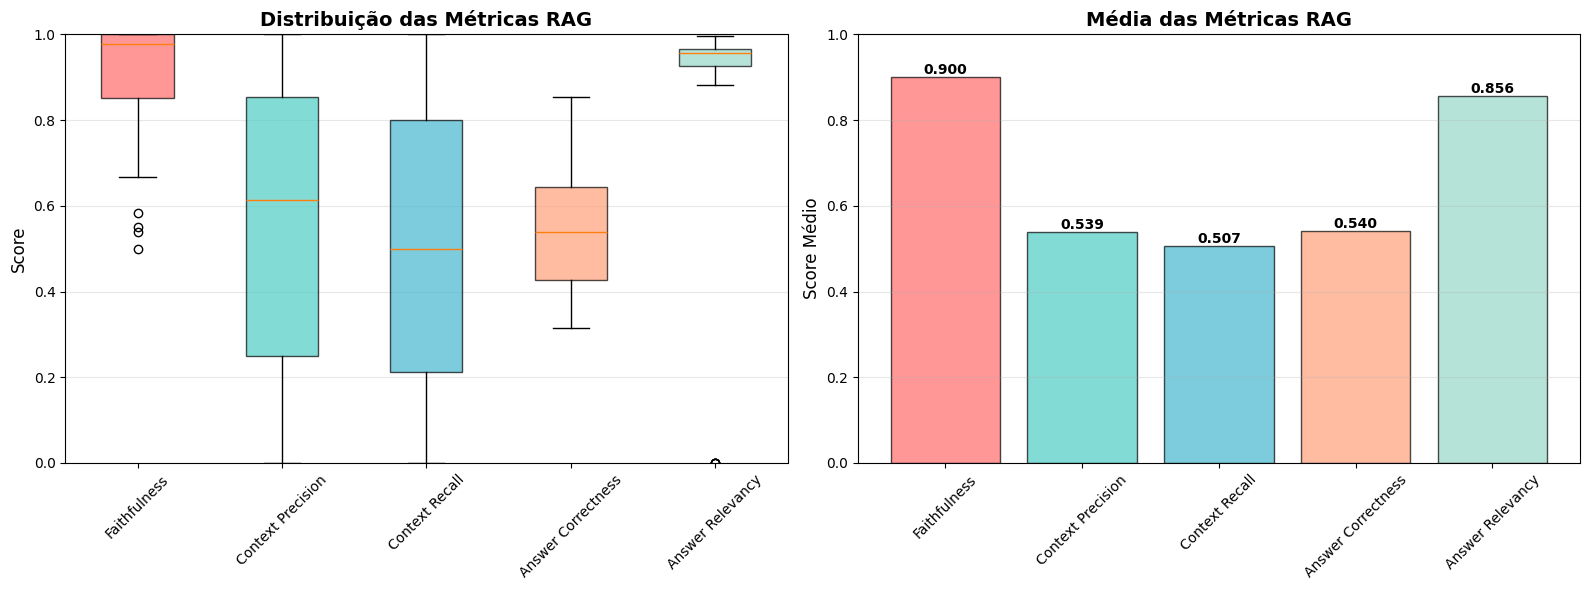


RESUMO FINAL
Faithfulness: 0.9001 (±0.1390)
Context Precision: 0.5390 (±0.3780)
Context Recall: 0.5065 (±0.3286)
Answer Correctness: 0.5400 (±0.1391)
Answer Relevancy: 0.8557 (±0.2861)


In [78]:
plot_data = []
plot_labels = []

for metric_name, values in metrics_data.items():
    if isinstance(values, list):
        # Remover NaN para visualização
        valid_values = [v for v in values if not np.isnan(v)]
        if valid_values:
            plot_data.append(valid_values)
            plot_labels.append(metric_name.replace("_", " ").title())

# Criar figura com boxplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
bp = ax1.boxplot(plot_data, labels=plot_labels, patch_artist=True)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Distribuição das Métricas RAG', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1)

# Colorir os boxes
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
for patch, color in zip(bp['boxes'], colors[:len(plot_data)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Rotacionar labels se necessário
ax1.tick_params(axis='x', rotation=45)

# Gráfico de barras com médias
means = [np.mean(data) for data in plot_data]
bars = ax2.bar(plot_labels, means, color=colors[:len(plot_data)], alpha=0.7, edgecolor='black')
ax2.set_ylabel('Score Médio', fontsize=12)
ax2.set_title('Média das Métricas RAG', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Adicionar valores nas barras
for bar, mean in zip(bars, means):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{mean:.3f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Estatísticas resumidas
print("\n" + "="*50)
print("RESUMO FINAL")
print("="*50)
for label, data in zip(plot_labels, plot_data):
    print(f"{label}: {np.mean(data):.4f} (±{np.std(data):.4f})")

<hr>

>save results

<hr>

In [24]:
eval_df.head(2)

,question,answer,contexts,ground_truth
0,What evidence is presented regarding the impac...,The evidence presented regarding the impact of...,[ABSTRACT\n\nCode comprehension is crucial in ...,The evidence regarding the impact of atoms of ...
1,What are the identified 'atoms of confusion' i...,The study identified 'atoms of confusion' as s...,[ABSTRACT\n\nCode comprehension is crucial in ...,Atoms of confusion are small code patterns in ...


In [25]:
eval_df["faithfulness"] = faithfulness_values 
eval_df["context_precision"] = context_precision_values 
eval_df["context_recall"] = context_recall_values 
eval_df["answer_correctness"] = answer_correctness_values 
eval_df["answer_relevancy"] = answer_relevancy_values

In [26]:
eval_df

,question,answer,contexts,ground_truth,faithfulness,context_precision,context_recall,answer_correctness,answer_relevancy
0,What evidence is presented regarding the impac...,The evidence presented regarding the impact of...,[ABSTRACT\n\nCode comprehension is crucial in ...,The evidence regarding the impact of atoms of ...,0.846154,0.770833,0.833333,0.852678,0.969227
1,What are the identified 'atoms of confusion' i...,The study identified 'atoms of confusion' as s...,[ABSTRACT\n\nCode comprehension is crucial in ...,Atoms of confusion are small code patterns in ...,1.000000,1.000000,0.250000,0.650784,0.951663
2,What experimental design was employed in the s...,The study employed a controlled experimental d...,[ABSTRACT\n\nCode comprehension is crucial in ...,The study employed a Latin Square design to as...,1.000000,0.750000,1.000000,0.646139,0.929804
3,What are the key findings of the empirical con...,The key findings of the empirical controlled e...,[ABSTRACT\n\nCode comprehension is crucial in ...,The empirical controlled experiment revealed t...,0.818182,1.000000,1.000000,0.651412,0.960531
4,What empirical evidence does the study provide...,The study provides empirical evidence that the...,[ABSTRACT\n\nCode comprehension is crucial in ...,The study provides empirical evidence that the...,0.909091,0.950000,1.000000,0.774499,0.920754
5,How does the presence of 'atoms of confusion' ...,The presence of 'atoms of confusion' in C prog...,[ABSTRACT\n\nCode comprehension is crucial in ...,The study investigates the effects of 'atoms o...,1.000000,0.666667,0.500000,0.474929,0.971178
6,How does the presence of atoms of confusion in...,The presence of atoms of confusion in C progra...,"[1 INTRODUCTION\n\nIn a previous study [4] , ...",The presence of atoms of confusion in C progra...,1.000000,0.166667,0.200000,0.448443,0.954785
7,How do atoms of confusion in C programming aff...,The presence of atoms of confusion in C progra...,"[1 INTRODUCTION\n\nIn summary, this paper pro...",Atoms of confusion in C programming significan...,1.000000,0.817857,1.000000,0.612959,0.959148
8,How does the experimental design using a Latin...,The experimental design using a Latin Square a...,"[1 INTRODUCTION\n\nIn summary, this paper pro...",The experimental design employed a Latin Squar...,1.000000,0.226190,1.000000,0.763518,0.965121
9,How does the experimental design using a Latin...,The experimental design using a Latin Square a...,"[1 INTRODUCTION\n\nIn a previous study [4] , ...",The experimental design employed a Latin Squar...,1.000000,0.200000,0.800000,0.697223,0.907079


In [27]:
eval_df.to_csv("test_data_ragas.csv")

In [14]:
result

{'faithfulness': 0.9001, 'answer_relevancy': 0.8557, 'context_precision': 0.4022, 'context_recall': 0.5065, 'answer_correctness': 0.5400}